In [ ]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")


In [2]:
PROJECT_ROOT = Path.cwd()

MODEL_DF_PATH = PROJECT_ROOT / "data" / "final_data" / "model_df.csv"
OUTPUT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "data" / "final_data"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not MODEL_DF_PATH.exists():
    raise FileNotFoundError(
        f"Could not find model_df.csv at: {MODEL_DF_PATH}\n"
        "Run this notebook from your project root folder, e.g. C:/Projects/Football Prediction"
    )

MODEL_DF_PATH


WindowsPath('c:/Projects/Football Prediction/data/final_data/model_df.csv')

In [3]:
model_df = pd.read_csv(MODEL_DF_PATH)

DATE_COL = "date"
TARGET_COL = "target"
CLASS_ORDER = [0, 1, 2]
CLASS_NAMES = ["Draw", "Team A win", "Team B win"]

model_df[DATE_COL] = pd.to_datetime(model_df[DATE_COL], errors="coerce")
model_df = model_df.dropna(subset=[DATE_COL, TARGET_COL]).copy()
model_df[TARGET_COL] = model_df[TARGET_COL].astype(int)

model_df = model_df.sort_values(DATE_COL).reset_index(drop=True)

print("Shape:", model_df.shape)
print("Date range:", model_df[DATE_COL].min(), "to", model_df[DATE_COL].max())

display(model_df.head())


Shape: (49453, 18)
Date range: 1872-11-30 00:00:00 to 2026-06-23 00:00:00


,neutral,is_team_a_home,is_friendly,is_world_cup,is_world_cup_qualifier,is_continental,team_a_points_last_5,team_b_points_last_5,points_last_5_diff,team_a_elo,team_b_elo,elo_diff,team_a_pi,team_b_pi,pi_diff,target,date,year
0,False,1,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,1872-11-30,1872
1,False,1,1,0,0,0,1.0,1.0,0.0,2006.0,1994.0,12.0,0.012500,-0.012500,0.025000,1,1873-03-08,1873
2,False,1,1,0,0,0,1.0,4.0,-3.0,1997.0,2003.0,-6.0,-0.098750,0.098750,-0.197500,1,1874-03-07,1874
3,False,1,1,0,0,0,4.0,4.0,0.0,1990.0,2011.0,-21.0,0.051375,-0.051375,0.102750,0,1875-03-06,1875
4,False,1,1,0,0,0,5.0,5.0,0.0,2011.0,1990.0,21.0,-0.033737,0.033737,-0.067475,1,1876-03-04,1876


In [4]:
model_df["year"] = model_df[DATE_COL].dt.year

print("Rows per year:")
display(model_df["year"].value_counts().sort_index())

print("\nTarget distribution overall:")
display(model_df[TARGET_COL].value_counts(normalize=True).reindex(CLASS_ORDER, fill_value=0))

print("\nTarget distribution by year:")
display(
    pd.crosstab(
        model_df["year"],
        model_df[TARGET_COL],
        normalize="index"
    ).round(3)
)

print("\n2026 matches:")
print((model_df["year"] == 2026).sum())


Rows per year:


year
1872       1
1873       1
1874       1
1875       1
1876       2
        ... 
2022     970
2023    1054
2024    1231
2025    1002
2026     359
Name: count, Length: 155, dtype: int64


Target distribution overall:


target
0    0.227428
1    0.490102
2    0.282470
Name: proportion, dtype: float64


Target distribution by year:


target,0,1,2
year,,,
1872,1.000,0.000,0.000
1873,0.000,1.000,0.000
1874,0.000,1.000,0.000
1875,1.000,0.000,0.000
1876,0.000,1.000,0.000
...,...,...,...
2022,0.227,0.498,0.275
2023,0.213,0.467,0.320
2024,0.249,0.461,0.289



2026 matches:
359


In [5]:
# Build feature list automatically from numeric columns.
# This keeps the notebook independent from the old notebook's feature_cols variable.

explicit_non_features = {
    DATE_COL,
    TARGET_COL,
    "year",
    "home_score",
    "away_score",
    "team_a_score",
    "team_b_score",
    "score_diff",
    "goal_diff",
    "actual_goal_diff",
    "pi_actual_goal_diff",
    "pi_error",
}

# Common text/id columns that should not be fed into the NN.
possible_text_cols = {
    "home_team",
    "away_team",
    "team_a",
    "team_b",
    "team",
    "opponent",
    "country",
    "city",
    "tournament",
}

numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    col for col in numeric_cols
    if col not in explicit_non_features
    and col not in possible_text_cols
]

# Extra leakage guard: remove obvious post-match score/result columns.
leakage_keywords = [
    "home_score",
    "away_score",
    "team_a_score",
    "team_b_score",
    "actual_goal",
    "pi_error",
]

feature_cols = [
    col for col in feature_cols
    if not any(keyword in col.lower() for keyword in leakage_keywords)
]

# Remove constant columns. They cannot help the NN.
constant_cols = [
    col for col in feature_cols
    if model_df[col].nunique(dropna=True) <= 1
]

feature_cols = [col for col in feature_cols if col not in constant_cols]

print("Number of features:", len(feature_cols))
print("\nRemoved constant columns:")
print(constant_cols)

print("\nFeatures:")
display(pd.DataFrame({"feature": feature_cols}))


Number of features: 13

Removed constant columns:
['is_team_a_home']

Features:


,feature
0,is_friendly
1,is_world_cup
2,is_world_cup_qualifier
3,is_continental
4,team_a_points_last_5
5,team_b_points_last_5
6,points_last_5_diff
7,team_a_elo
8,team_b_elo
9,elo_diff


In [6]:
TRAIN_END_2023 = pd.Timestamp("2023-12-31")
CV_START = pd.Timestamp("2024-01-01")
CV_END = pd.Timestamp("2025-12-31")
TEST_START_2026 = pd.Timestamp("2026-01-01")
TRAIN_END_2025 = pd.Timestamp("2025-12-31")

train_to_2023_df = model_df[model_df[DATE_COL] <= TRAIN_END_2023].copy()

calibration_2024_2025_df = model_df[
    (model_df[DATE_COL] >= CV_START) &
    (model_df[DATE_COL] <= CV_END)
].copy()

train_to_2025_df = model_df[model_df[DATE_COL] <= TRAIN_END_2025].copy()

test_2026_df = model_df[model_df[DATE_COL] >= TEST_START_2026].copy()

print("Date-based split sizes")
print("-" * 35)
print("Train <= 2023:", len(train_to_2023_df))
print("Calibration 2024-2025:", len(calibration_2024_2025_df))
print("Train <= 2025:", len(train_to_2025_df))
print("Final test 2026:", len(test_2026_df))

if len(test_2026_df) == 0:
    raise ValueError("No 2026 matches found. Final 2026 test cannot run.")

print("\n2026 target distribution:")
display(test_2026_df[TARGET_COL].value_counts(normalize=True).reindex(CLASS_ORDER, fill_value=0))


Date-based split sizes
-----------------------------------
Train <= 2023: 46861
Calibration 2024-2025: 2233
Train <= 2025: 49094
Final test 2026: 359

2026 target distribution:


target
0    0.253482
1    0.498607
2    0.247911
Name: proportion, dtype: float64

In [7]:
def get_X_y(df):
    X = df[feature_cols].copy()
    y = df[TARGET_COL].astype(int).copy()
    return X, y


EPS = 1e-15


def normalise_proba(y_proba):
    y_proba = np.asarray(y_proba, dtype=float)
    y_proba = np.clip(y_proba, EPS, 1.0)
    y_proba = y_proba / y_proba.sum(axis=1, keepdims=True)
    return y_proba


def align_proba_to_class_order(y_proba, model_classes, class_order=CLASS_ORDER):
    y_proba = np.asarray(y_proba, dtype=float)
    model_classes = list(model_classes)

    aligned = np.zeros((len(y_proba), len(class_order)))

    for output_idx, class_label in enumerate(class_order):
        if class_label in model_classes:
            input_idx = model_classes.index(class_label)
            aligned[:, output_idx] = y_proba[:, input_idx]

    return normalise_proba(aligned)


def multiclass_brier_score(y_true, y_proba, class_order=CLASS_ORDER):
    y_true_onehot = label_binarize(y_true, classes=class_order)
    y_proba = normalise_proba(y_proba)

    return np.mean(np.sum((y_proba - y_true_onehot) ** 2, axis=1))


def ranked_probability_score(y_true, y_proba, class_order=CLASS_ORDER):
    y_true_onehot = label_binarize(y_true, classes=class_order)
    y_proba = normalise_proba(y_proba)

    cumulative_proba = np.cumsum(y_proba, axis=1)
    cumulative_true = np.cumsum(y_true_onehot, axis=1)

    return np.mean(
        np.sum((cumulative_proba - cumulative_true) ** 2, axis=1)
        / (len(class_order) - 1)
    )


def evaluate_predictions(y_true, y_pred, y_proba, metadata=None):
    if metadata is None:
        metadata = {}

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int).ravel()
    y_proba = normalise_proba(y_proba)

    return {
        **metadata,
        "n_matches": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, y_proba, labels=CLASS_ORDER),
        "brier": multiclass_brier_score(y_true, y_proba, CLASS_ORDER),
        "rps": ranked_probability_score(y_true, y_proba, CLASS_ORDER),
    }


def evaluate_model_on_df(model, eval_df, metadata=None):
    X_eval, y_eval = get_X_y(eval_df)

    y_pred = model.predict(X_eval)
    y_pred = np.asarray(y_pred).ravel().astype(int)

    y_proba = model.predict_proba(X_eval)
    model_classes = getattr(model, "classes_", CLASS_ORDER)
    y_proba = align_proba_to_class_order(y_proba, model_classes, CLASS_ORDER)

    return evaluate_predictions(y_eval, y_pred, y_proba, metadata)


In [8]:
def evaluate_majority_baseline(train_df, eval_df, metadata=None):
    if metadata is None:
        metadata = {}

    _, y_train = get_X_y(train_df)
    _, y_eval = get_X_y(eval_df)

    majority_class = y_train.mode()[0]

    train_class_probs = (
        y_train.value_counts(normalize=True)
        .reindex(CLASS_ORDER, fill_value=0)
        .values
    )

    y_pred = np.full(shape=len(y_eval), fill_value=majority_class)
    y_proba = np.tile(train_class_probs, (len(y_eval), 1))

    return evaluate_predictions(
        y_eval,
        y_pred,
        y_proba,
        {
            **metadata,
            "model": "Majority baseline",
            "calibration": "none",
        }
    )


In [22]:
def make_nn_model(random_state=42):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-3,
                batch_size=128,
                learning_rate_init=1e-3,
                max_iter=250,
                n_iter_no_change=15,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=random_state,
                verbose=True,
            )),
        ]
    )


nn_model = make_nn_model()
nn_model


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [23]:
def make_prefit_calibrator(fitted_model, method):
    """
    Create a calibrated classifier from an already fitted model.

    Uses FrozenEstimator when available.
    Falls back to cv='prefit' for older sklearn versions.
    """

    try:
        from sklearn.frozen import FrozenEstimator

        return CalibratedClassifierCV(
            estimator=FrozenEstimator(fitted_model),
            method=method
        )

    except Exception:
        signature = inspect.signature(CalibratedClassifierCV)

        if "estimator" in signature.parameters:
            return CalibratedClassifierCV(
                estimator=fitted_model,
                method=method,
                cv="prefit"
            )

        return CalibratedClassifierCV(
            base_estimator=fitted_model,
            method=method,
            cv="prefit"
        )


In [24]:
results = []
trained_models = {}

# Baseline on 2026
results.append(
    evaluate_majority_baseline(
        train_to_2025_df,
        test_2026_df,
        metadata={
            "experiment": "final_2026_nn",
            "model": "Majority baseline",
            "train_data": "<=2025",
            "calibration_data": "none",
            "test_data": "2026",
        }
    )
)

display(pd.DataFrame(results))


,experiment,model,train_data,calibration_data,test_data,calibration,n_matches,accuracy,macro_f1,log_loss,brier,rps
0,final_2026_nn,Majority baseline,<=2025,none,2026,none,359,0.498607,0.221809,1.044423,0.627652,0.18879


In [25]:
# Uncalibrated NN:
# train on all data up to 2025, test once on 2026.

X_train_2025, y_train_2025 = get_X_y(train_to_2025_df)

nn_uncalibrated = make_nn_model(random_state=42)
nn_uncalibrated.fit(X_train_2025, y_train_2025)

trained_models["NN uncalibrated <=2025"] = nn_uncalibrated

results.append(
    evaluate_model_on_df(
        nn_uncalibrated,
        test_2026_df,
        metadata={
            "experiment": "final_2026_nn",
            "model": "Neural Network",
            "train_data": "<=2025",
            "calibration": "none",
            "calibration_data": "none",
            "test_data": "2026",
        }
    )
)

results_df = pd.DataFrame(results).sort_values(
    ["rps", "log_loss", "brier", "accuracy"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

display(results_df)

Iteration 1, loss = 0.91386540
Validation score: 0.586965
Iteration 2, loss = 0.90463906
Validation score: 0.588595
Iteration 3, loss = 0.90266272
Validation score: 0.581942
Iteration 4, loss = 0.90186122
Validation score: 0.585064
Iteration 5, loss = 0.90183016
Validation score: 0.584793
Iteration 6, loss = 0.90224091
Validation score: 0.588323
Iteration 7, loss = 0.90036640
Validation score: 0.585879
Iteration 8, loss = 0.90128520
Validation score: 0.583707
Iteration 9, loss = 0.89983036
Validation score: 0.585879
Iteration 10, loss = 0.90030598
Validation score: 0.587780
Iteration 11, loss = 0.89986764
Validation score: 0.585743
Iteration 12, loss = 0.89849594
Validation score: 0.586830
Iteration 13, loss = 0.89824068
Validation score: 0.586558
Iteration 14, loss = 0.89803204
Validation score: 0.583164
Iteration 15, loss = 0.89803995
Validation score: 0.583842
Iteration 16, loss = 0.89753497
Validation score: 0.587916
Iteration 17, loss = 0.89710519
Validation score: 0.585608
Iterat

,experiment,model,train_data,calibration_data,test_data,calibration,n_matches,accuracy,macro_f1,log_loss,brier,rps
0,final_2026_nn,Neural Network,<=2025,none,2026,none,359,0.571031,0.408359,0.883440,0.521878,0.164074
1,final_2026_nn,Majority baseline,<=2025,none,2026,none,359,0.498607,0.221809,1.044423,0.627652,0.188790


In [26]:
# Calibrated NN:
# fit base NN on <=2023, calibrate on 2024-2025, test once on 2026.

X_fit_2023, y_fit_2023 = get_X_y(train_to_2023_df)
X_cal_2024_2025, y_cal_2024_2025 = get_X_y(calibration_2024_2025_df)

for method in ["sigmoid", "isotonic"]:
    print(f"Training calibrated NN with {method} calibration")

    base_nn = make_nn_model(random_state=42)
    base_nn.fit(X_fit_2023, y_fit_2023)

    calibrated_nn = make_prefit_calibrator(base_nn, method=method)
    calibrated_nn.fit(X_cal_2024_2025, y_cal_2024_2025)

    model_key = f"NN calibrated {method}"
    trained_models[model_key] = calibrated_nn

    results.append(
        evaluate_model_on_df(
            calibrated_nn,
            test_2026_df,
            metadata={
                "experiment": "final_2026_nn",
                "model": "Neural Network",
                "train_data": "<=2023",
                "calibration": method,
                "calibration_data": "2024-2025",
                "test_data": "2026",
            }
        )
    )

results_df = pd.DataFrame(results).sort_values(
    ["rps", "log_loss", "brier", "accuracy"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

display(results_df)


Training calibrated NN with sigmoid calibration
Iteration 1, loss = 0.91525834
Validation score: 0.570839
Iteration 2, loss = 0.90449112
Validation score: 0.573969
Iteration 3, loss = 0.90326852
Validation score: 0.573400
Iteration 4, loss = 0.90241079
Validation score: 0.573542
Iteration 5, loss = 0.90131420
Validation score: 0.572262
Iteration 6, loss = 0.90119853
Validation score: 0.574822
Iteration 7, loss = 0.90086229
Validation score: 0.575391
Iteration 8, loss = 0.90003042
Validation score: 0.573542
Iteration 9, loss = 0.89971275
Validation score: 0.572973
Iteration 10, loss = 0.89943184
Validation score: 0.575391
Iteration 11, loss = 0.89914612
Validation score: 0.576245
Iteration 12, loss = 0.89870809
Validation score: 0.578236
Iteration 13, loss = 0.89868977
Validation score: 0.577098
Iteration 14, loss = 0.89854134
Validation score: 0.574680
Iteration 15, loss = 0.89785072
Validation score: 0.573969
Iteration 16, loss = 0.89773509
Validation score: 0.574395
Iteration 17, los

,experiment,model,train_data,calibration_data,test_data,calibration,n_matches,accuracy,macro_f1,log_loss,brier,rps
0,final_2026_nn,Neural Network,<=2025,none,2026,none,359,0.571031,0.408359,0.883440,0.521878,0.164074
1,final_2026_nn,Neural Network,<=2023,2024-2025,2026,sigmoid,359,0.562674,0.452015,0.888094,0.521824,0.164830
2,final_2026_nn,Neural Network,<=2023,2024-2025,2026,isotonic,359,0.571031,0.422191,0.886536,0.524462,0.165414
3,final_2026_nn,Majority baseline,<=2025,none,2026,none,359,0.498607,0.221809,1.044423,0.627652,0.188790


In [ ]:
# Save results and trained models.
results_path = RESULTS_DIR / "nn_2026_results.csv"
results_df.to_csv(results_path, index=False)

for model_name, model_obj in trained_models.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("<=", "to_")
        .replace("/", "_")
    )
    joblib.dump(model_obj, OUTPUT_DIR / f"{safe_name}.joblib")

print("Saved results to:", results_path)
print("Saved models to:", OUTPUT_DIR)


Saved results to: c:\Projects\Football Prediction\data\final_data\nn_2026_results.csv
Saved models to: c:\Projects\Football Prediction\models


In [28]:
# Show the best model by probability quality.
# Main ranking: lowest RPS, then lowest log loss, then lowest Brier, then highest accuracy.

best_row = results_df.iloc[0]
best_model_key = None

if best_row["model"] == "Majority baseline":
    print("Best row is the majority baseline. This usually means the NN is weak or 2026 test set is very small.")
else:
    if best_row["calibration"] == "none":
        best_model_key = "NN uncalibrated <=2025"
    else:
        best_model_key = f"NN calibrated {best_row['calibration']}"

    print("Best model key:", best_model_key)
    display(best_row.to_frame().T)


Best model key: NN uncalibrated <=2025


,experiment,model,train_data,calibration_data,test_data,calibration,n_matches,accuracy,macro_f1,log_loss,brier,rps
0,final_2026_nn,Neural Network,<=2025,none,2026,none,359,0.571031,0.408359,0.88344,0.521878,0.164074


              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00        91
  Team A win       0.58      0.89      0.70       179
  Team B win       0.54      0.51      0.52        89

    accuracy                           0.57       359
   macro avg       0.37      0.47      0.41       359
weighted avg       0.42      0.57      0.48       359



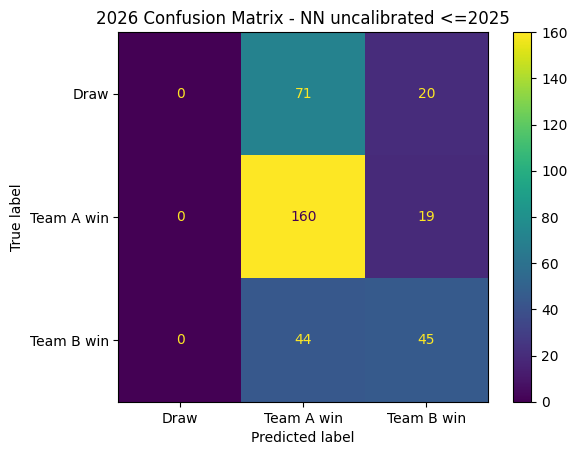

In [29]:
# Classification report and confusion matrix for the best NN model.

if best_model_key is not None:
    best_model = trained_models[best_model_key]

    X_test_2026, y_test_2026 = get_X_y(test_2026_df)

    y_pred_2026 = best_model.predict(X_test_2026)
    y_pred_2026 = np.asarray(y_pred_2026).ravel().astype(int)

    print(classification_report(
        y_test_2026,
        y_pred_2026,
        labels=CLASS_ORDER,
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test_2026,
        y_pred_2026,
        labels=CLASS_ORDER,
        display_labels=CLASS_NAMES,
    )
    plt.title(f"2026 Confusion Matrix - {best_model_key}")
    plt.show()


In [30]:
# Save 2026 match-level predictions from the best NN model.

if best_model_key is not None:
    best_model = trained_models[best_model_key]
    X_test_2026, y_test_2026 = get_X_y(test_2026_df)

    y_pred_2026 = best_model.predict(X_test_2026)
    y_pred_2026 = np.asarray(y_pred_2026).ravel().astype(int)

    y_proba_2026 = best_model.predict_proba(X_test_2026)
    model_classes = getattr(best_model, "classes_", CLASS_ORDER)
    y_proba_2026 = align_proba_to_class_order(y_proba_2026, model_classes, CLASS_ORDER)

    prediction_cols = [DATE_COL, TARGET_COL]
    for optional_col in ["team_a", "team_b", "home_team", "away_team", "tournament"]:
        if optional_col in test_2026_df.columns:
            prediction_cols.append(optional_col)

    predictions_df = test_2026_df[prediction_cols].copy()
    predictions_df["predicted_target"] = y_pred_2026
    predictions_df["prob_draw"] = y_proba_2026[:, 0]
    predictions_df["prob_team_a_win"] = y_proba_2026[:, 1]
    predictions_df["prob_team_b_win"] = y_proba_2026[:, 2]

    predictions_path = RESULTS_DIR / "nn_2026_predictions.csv"
    predictions_df.to_csv(predictions_path, index=False)

    display(predictions_df.head())
    print("Saved predictions to:", predictions_path)


,date,target,predicted_target,prob_draw,prob_team_a_win,prob_team_b_win
49094,2026-01-03,1,1,0.098932,0.875307,0.025761
49095,2026-01-03,0,1,0.301687,0.457566,0.240748
49096,2026-01-04,1,1,0.123349,0.844258,0.032393
49097,2026-01-04,2,1,0.301758,0.436144,0.262098
49098,2026-01-05,1,1,0.221835,0.671279,0.106887


Saved predictions to: c:\Projects\Football Prediction\data\final_data\nn_2026_predictions.csv
